In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


In [115]:
# Load data from files
class1 = np.loadtxt('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class1.txt')
class2 = np.loadtxt('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class2.txt')
class3 = np.loadtxt('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class3.txt')


# Assign labels (1-based indexing)
labels_class1 = np.ones((class1.shape[0], 1))       # Class 1
labels_class2 = np.full((class2.shape[0], 1), 2)   # Class 2
labels_class3 = np.full((class3.shape[0], 1), 3)   # Class 3

# Combine data and labels
data = np.vstack((class1, class2, class3))
labels = np.vstack((labels_class1, labels_class2, labels_class3)).flatten()

# Split data into training (70%) and testing (30%)
train_size = int(0.7 * data.shape[0])
indices = np.random.permutation(data.shape[0])
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train, X_test = data[train_indices], data[test_indices]
y_train, y_test = labels[train_indices], labels[test_indices]


In [117]:
class Perceptron:
    def __init__(self, num_features, num_classes, learning_rate=0.01, epochs=1000):
        self.weights = np.random.rand(num_classes, num_features + 1) * 0.01  # +1 for bias
        self.learning_rate = learning_rate
        self.epochs = epochs

    def _add_bias(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1))])  # Add bias term

    def train(self, X, y):
        X = self._add_bias(X)
        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                predicted = self.predict_single(xi)
                if predicted != target:
                    self.weights[int(target) - 1] += self.learning_rate * xi  # Adjust weights for target
                    self.weights[int(predicted) - 1] -= self.learning_rate * xi  # Penalize incorrect class

    def predict_single(self, xi):
        return np.argmax(np.dot(self.weights, xi)) + 1  # Return 1-based class

    def predict(self, X):
        X = self._add_bias(X)
        return np.array([self.predict_single(xi) for xi in X])


In [119]:
# Initialize and train perceptron
perceptron = Perceptron(num_features=2, num_classes=3, learning_rate=0.01, epochs=1000)
perceptron.train(X_train, y_train)


In [120]:
# Predict on the test set
y_pred = perceptron.predict(X_test)

# Overall confusion matrix and metrics
conf_matrix = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)
precision = precision_score(y_test, y_pred, average=None, labels=[1, 2, 3])
recall = recall_score(y_test, y_pred, average=None, labels=[1, 2, 3])
f1 = f1_score(y_test, y_pred, average=None, labels=[1, 2, 3])

print("Confusion Matrix:\n", conf_matrix)
print("Accuracy:", accuracy)
print("Precision per class:", precision)
print("Mean Precision:", np.mean(precision))
print("Recall per class:", recall)
print("Mean Recall:", np.mean(recall))
print("F-Measure per class:", f1)
print("Mean F-Measure:", np.mean(f1))


Confusion Matrix:
 [[146   0   0]
 [  0 141   0]
 [  0   1 162]]
Accuracy: 0.9977777777777778
Precision per class: [1.         0.99295775 1.        ]
Mean Precision: 0.9976525821596244
Recall per class: [1.         1.         0.99386503]
Mean Recall: 0.9979550102249489
F-Measure per class: [1.         0.99646643 0.99692308]
Mean F-Measure: 0.9977965026728278


In [121]:
# Pairwise evaluation for updated class pairs
class_pairs = [(1, 2), (2, 3), (3, 1)]
for pair in class_pairs:
    mask = np.isin(y_test, pair)
    y_test_pair = y_test[mask]
    y_pred_pair = y_pred[mask]
    pair_matrix = confusion_matrix(y_test_pair, y_pred_pair, labels=pair)
    print(f"Confusion Matrix for classes {pair}:\n", pair_matrix)
    print(f"Accuracy for classes {pair}: {np.trace(pair_matrix) / np.sum(pair_matrix)}")
    pair_precision = precision_score(y_test_pair, y_pred_pair, average=None, labels=pair)
    pair_recall = recall_score(y_test_pair, y_pred_pair, average=None, labels=pair)
    pair_f1 = f1_score(y_test_pair, y_pred_pair, average=None, labels=pair)
    print(f"Precision for classes {pair}: {pair_precision}")
    print(f"Recall for classes {pair}: {pair_recall}")
    print(f"F-Measure for classes {pair}: {pair_f1}")


Confusion Matrix for classes (1, 2):
 [[146   0]
 [  0 141]]
Accuracy for classes (1, 2): 1.0
Precision for classes (1, 2): [1. 1.]
Recall for classes (1, 2): [1. 1.]
F-Measure for classes (1, 2): [1. 1.]
Confusion Matrix for classes (2, 3):
 [[141   0]
 [  1 162]]
Accuracy for classes (2, 3): 0.9967105263157895
Precision for classes (2, 3): [0.99295775 1.        ]
Recall for classes (2, 3): [1.         0.99386503]
F-Measure for classes (2, 3): [0.99646643 0.99692308]
Confusion Matrix for classes (3, 1):
 [[162   0]
 [  0 146]]
Accuracy for classes (3, 1): 1.0
Precision for classes (3, 1): [1. 1.]
Recall for classes (3, 1): [0.99386503 1.        ]
F-Measure for classes (3, 1): [0.99692308 1.        ]


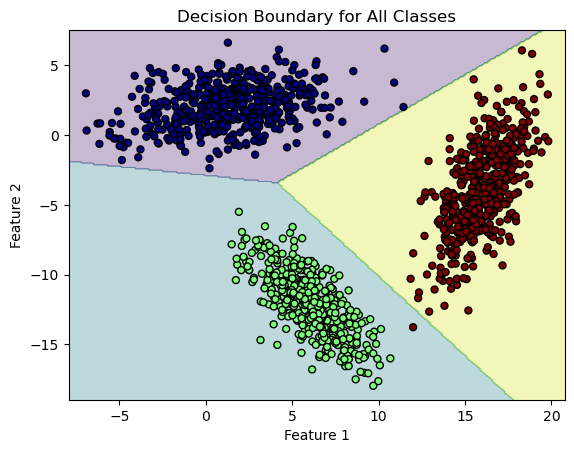

In [125]:

def plot_decision_boundary(model, X, y, classes=None):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=25, cmap='jet')
    if classes:
        plt.title(f"Decision Boundary for Classes {classes}")
    else:
        plt.title("Decision Boundary for All Classes")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Plot for all classes
plot_decision_boundary(perceptron, data, labels)


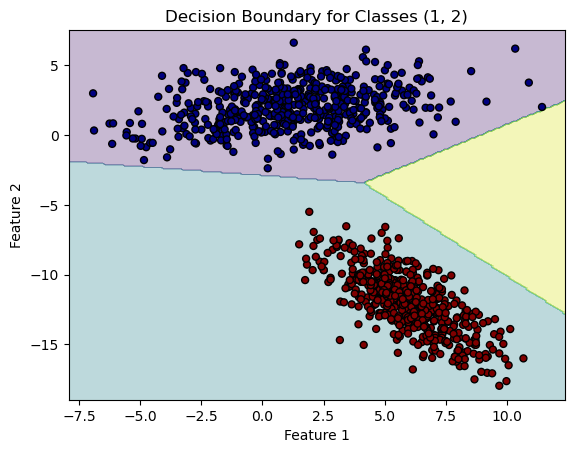

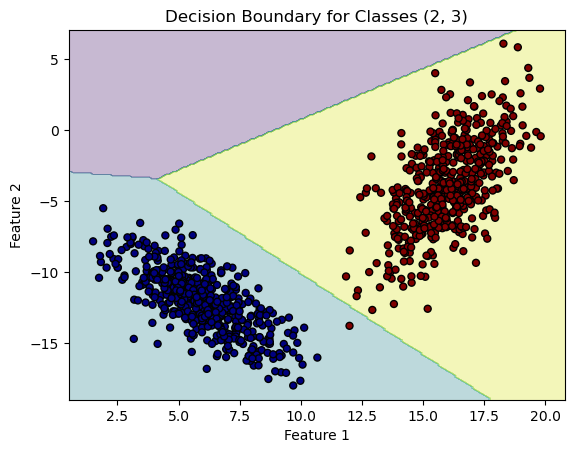

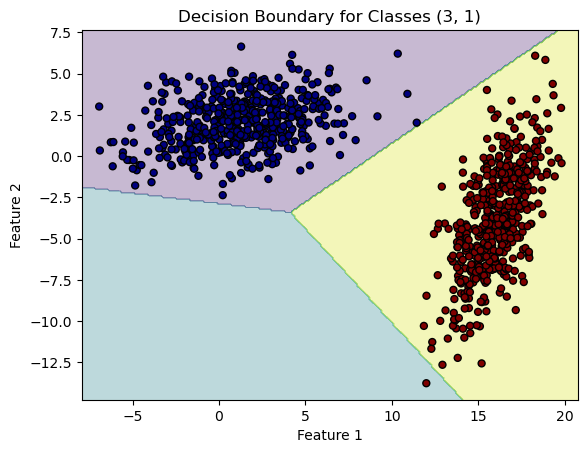

In [127]:
# Pairwise plots for updated class pairs
for pair in class_pairs:
    mask = np.isin(labels, pair)
    plot_decision_boundary(perceptron, data[mask], labels[mask], classes=pair)
